<a href="https://colab.research.google.com/github/ZoeyGuo709/musa-650-spring-2025/blob/main/week10/s1_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q1. Classifying the 7 classes in the Covertype dataset from the UCI Machine Learning Repository using an SVM classifier

## Steps:

1. Data Preparation:

- Load the Dataset: Use Pandas to load the covtype.data file (https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz)
- Separate input features and output labels
- Feature Scaling: SVMs are sensitive to feature scaling. Apply StandardScaler to scale the features.
- Train-Validation-Test Split: Split the data into training, validation and testing sets.


In [5]:
# prompt: Load the Dataset: Use Pandas to load the covtype.data file (https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz)

import pandas as pd

# 1. Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
df = pd.read_csv(url, header=None)

df.head()




,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [12]:
unique_values = df[54].unique()
print("unique values of target data:", unique_values)

unique values of target data: [5 2 1 7 3 6 4]


In [13]:
# 2. Separate input features and output labels
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


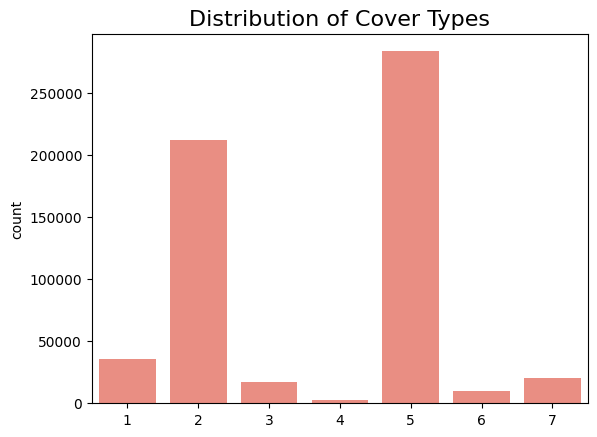

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_y=y.unique()
counts_y=y.value_counts()

bar = sns.barplot(x=unique_y, y=counts_y, color="salmon")
bar.set_title('Distribution of Cover Types', fontsize=16)

plt.show()

In [17]:
# prompt: feature scaling

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X = scaler.fit_transform(X)


In [18]:
X

array([[-1.29780509, -0.93515698, -1.48281978, ..., -0.16595612,
        -0.15601398, -0.12365355],
       [-1.31923485, -0.89047967, -1.61636259, ..., -0.16595612,
        -0.15601398, -0.12365355],
       [-0.5549068 , -0.14883628, -0.68156292, ..., -0.16595612,
        -0.15601398, -0.12365355],
       ...,
       [-2.04784663,  0.02987297,  0.38677957, ..., -0.16595612,
        -0.15601398, -0.12365355],
       [-2.05498988,  0.12816306,  0.11969395, ..., -0.16595612,
        -0.15601398, -0.12365355],
       [-2.05856151,  0.08348575, -0.14739167, ..., -0.16595612,
        -0.15601398, -0.12365355]])

In [23]:
# prompt: Train-Validation-Test Split: Split the data into training, validation and testing sets, first 11340 records for training, next 3780 for validation, last 565892 for testing data

from sklearn.model_selection import train_test_split

# Split data into training, validation and testing sets
X_train = X[0:11340,:]
y_train = y[0:11340]

X_val = X[11340:11340 + 3780,:]
y_val = y[11340:11340 + 3780]

X_test = X[11340 + 3780:,:]
y_test = y[11340 + 3780:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (11340, 54)
y_train shape: (11340,)
X_val shape: (3780, 54)
y_val shape: (3780,)
X_test shape: (565892, 54)
y_test shape: (565892,)


2. SVM Classifier Selection and Parameter Tuning:

- Kernel Selection: For complex, non-linear datasets like Covertype, the Radial Basis Function (RBF) kernel is often a good choice.
- A linear kernel may also be considered, as it may be much faster.
- C (Regularization Parameter): Controls the trade-off between maximizing the margin and minimizing the training error.
- gamma (Kernel Coefficient): Defines the influence of a single training example.
- Use GridSearchCV or RandomizedSearchCV for efficient parameter tuning.
- Multi-class Strategy: Scikit-learn's SVC automatically handles multi-class classification using the "one-vs-one" strategy.


In [41]:
# prompt: For complex, non-linear datasets like Covertype, the Radial Basis Function (RBF) kernel is often a good choice. apply this kernel

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


# Create an SVC classifier with an RBF kernel
svm_classifier = SVC(kernel='rbf')

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best parameters:", best_params)


# Make predictions on the validation set
y_pred_val = best_estimator.predict(X_val)

# Calculate the accuracy on the validation set
accuracy_val = accuracy_score(y_val, y_pred_val)
print("Validation accuracy:", accuracy_val)

# Make predictions on the test set
y_pred_test = best_estimator.predict(X_test)

# Calculate the accuracy on the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Test accuracy:", accuracy_test)


Best parameters: {'C': 1, 'gamma': 0.01}
Validation accuracy: 0.7312169312169312
Test accuracy: 0.6073084616852685


3. Application on test data

- Perform prediction on the test dataset
- Confusion Matrix Calculation
- Confusion Matrix Visualization: Use matplotlib.pyplot and seaborn to create a visually appealing heatmap of the confusion matrix.

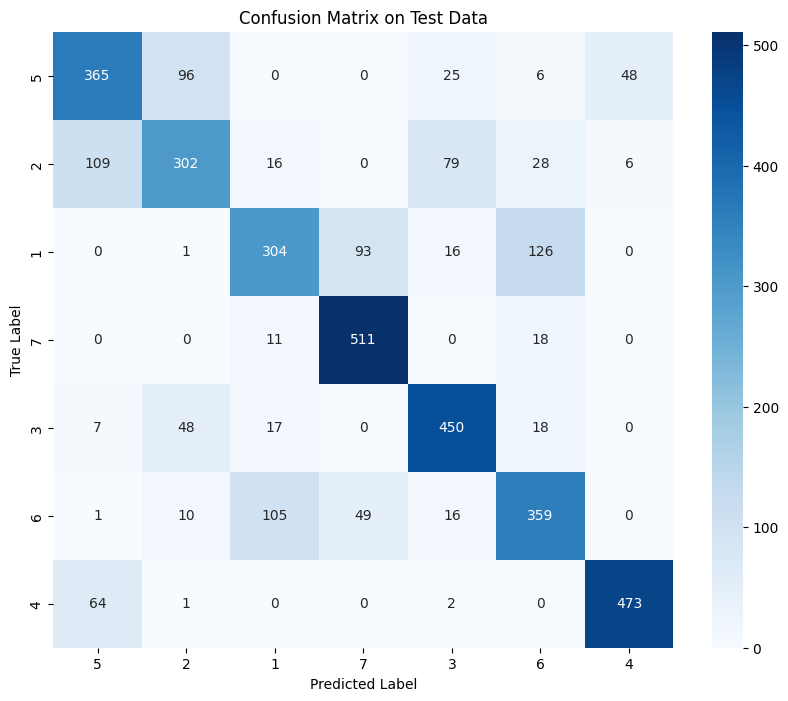

In [96]:
# prompt: Perform prediction on the test dataset
# Confusion Matrix Calculation
# Confusion Matrix Visualization: Use matplotlib.pyplot and seaborn to create a visually appealing heatmap of the confusion matrix.

from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred_val)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_y, yticklabels=unique_y)
plt.title("Confusion Matrix on Test Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


4. SVM Classifier between 2 classes to practice basic data manipulation using numpy

- Create a plot with the counts of the labels in the training, validation and test sets
- Select the two labels with the largest number of samples
- Print samples from the selected classes
- Train a linear svm using the training data and calculate the accuracy on the testing data

In [77]:
Unique_values_y_train = np.unique(y_train)

Unique_values_y_train

array([1, 2, 3, 4, 5, 6, 7])

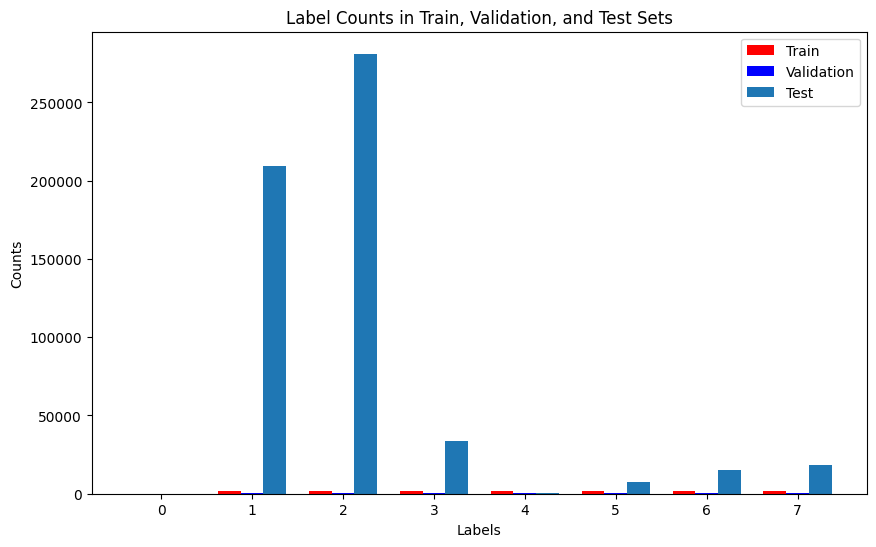

In [58]:
# prompt: SVM Classifier between 2 classes to practice basic data manipulation using numpy
# Create a plot with the counts of the labels in the training, validation and test sets
# Select the two labels with the largest number of samples
# Print samples from the selected classes
# Train a linear svm using the training data and calculate the accuracy on the testing data

import numpy as np

# Create a plot with the counts of the labels in the training, validation and test sets
train_counts = np.bincount(y_train)
val_counts = np.bincount(y_val)
test_counts = np.bincount(y_test)

plt.figure(figsize=(10, 6))
x = np.arange(len(train_counts))
width = 0.25

plt.bar(x - width, train_counts, width, label='Train', color = "red")
plt.bar(x, val_counts, width, label='Validation', color = "blue")
plt.bar(x + width, test_counts, width, label='Test')

plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Label Counts in Train, Validation, and Test Sets')
plt.legend()
plt.show()





In [91]:
# Select the two labels with the largest number of samples
top_two_labels = np.argsort(train_counts + val_counts + test_counts)[-2:]
print("Top two labels:", top_two_labels)

# Filter the data for the selected classes
# Use boolean indexing for filtering
train_mask = np.isin(y_train, top_two_labels)
X_train_filtered = X_train[train_mask]
y_train_filtered = y_train[train_mask]

test_mask = np.isin(y_test, top_two_labels)
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]

Top two labels: [1 2]


In [94]:
y_train_filtered.shape

(3240,)

In [98]:
# Replace y_train_filtered.value() with the appropriate NumPy method

import numpy as np

# To get the most frequent value:
most_frequent_value = np.argmax(np.bincount(y_train_filtered))
print(f"Most frequent value in y_train_filtered: {most_frequent_value}")

# To get unique values and their counts:
unique_values, counts = np.unique(y_train_filtered, return_counts=True)
print(f"Unique values and counts in y_train_filtered: {dict(zip(unique_values, counts))}")

Most frequent value in y_train_filtered: 1
Unique values and counts in y_train_filtered: {np.int64(1): np.int64(1620), np.int64(2): np.int64(1620)}


In [92]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train a linear SVM using the training data
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_filtered, y_train_filtered)

# Make predictions on the test data
y_pred_linear = svm_linear.predict(X_test_filtered)

# Calculate the accuracy on the test data
accuracy_linear = accuracy_score(y_test_filtered, y_pred_linear)

# Print the accuracy
print("Accuracy of linear SVM on the test data:", accuracy_linear)

Accuracy of linear SVM on the test data: 0.7716927352334151


5. Train a neural network for classification


In [103]:
# prompt: neural network for classificaiton'

from tensorflow import keras
from tensorflow.keras import layers

# Define the neural network model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax')  # Output layer with softmax for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse categorical crossentropy for integer labels
              metrics=['accuracy'])

# Subtract 1 from y_train and y_val to shift the labels to the range [0, 6]
y_train_shifted = y_train - 1
y_val_shifted = y_val - 1
y_test_shifted = y_test - 1

# Train the model
model.fit(X_train, y_train_shifted, epochs=10, batch_size=32, validation_data=(X_val, y_val_shifted))




Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5454 - loss: 1.2053 - val_accuracy: 0.6841 - val_loss: 0.7568
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7098 - loss: 0.7090 - val_accuracy: 0.7198 - val_loss: 0.6878
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7340 - loss: 0.6543 - val_accuracy: 0.7286 - val_loss: 0.6561
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7505 - loss: 0.6082 - val_accuracy: 0.7489 - val_loss: 0.6137
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7544 - loss: 0.5851 - val_accuracy: 0.7574 - val_loss: 0.5890
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7678 - loss: 0.5526 - val_accuracy: 0.7601 - val_loss: 0.5815
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7765 - loss: 0.5390 - val_accuracy: 0.7606 - val_loss: 0.5692
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7839 - loss: 0.5176 - val_accuracy: 0.7608 - val_

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_shifted)
print('Test accuracy:', accuracy)

# Make predictions on the test set
y_pred_nn = np.argmax(model.predict(X_test), axis=1)

# Calculate the confusion matrix
cm_nn = confusion_matrix(y_test_shifted, y_pred_nn)

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Blues", xticklabels=unique_y, yticklabels=unique_y)
plt.title("Confusion Matrix for Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

17685/17685 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.7170 - loss: 0.6525
Test accuracy: 0.6639235019683838
17685/17685 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step
